In [1]:
import pandas as pd

inventory = pd.read_csv(
    "../data/raw/inventory_transactions.csv"
)

ingredients = pd.read_csv(
    "../data/raw/ingredients.csv"
)

recipes = pd.read_csv(
    "../data/raw/product_ingredients.csv"
)

products = pd.read_csv(
    "../data/raw/products.csv"
)

print("Inventory:")
display(inventory.head())

print("\nInventory columns:")
print(inventory.columns.tolist())

print("\nIngredients:")
display(ingredients.head())

print("\nIngredient columns:")
print(ingredients.columns.tolist())

print("\nRecipes:")
display(recipes.head())

print("\nRecipe columns:")
print(recipes.columns.tolist())

Inventory:


,date,branch_id,ingredient_id,opening_stock,received_stock,used_stock,closing_stock
0,2024-01-01,B001,I001,219.07,479.99,120.00,579.06
1,2024-01-02,B001,I001,579.06,0.00,115.03,464.03
2,2024-01-03,B001,I001,464.03,0.00,93.04,370.99
3,2024-01-04,B001,I001,370.99,0.00,117.42,253.56
4,2024-01-05,B001,I001,253.56,390.03,97.51,546.09



Inventory columns:
['date', 'branch_id', 'ingredient_id', 'opening_stock', 'received_stock', 'used_stock', 'closing_stock']

Ingredients:


,ingredient_id,ingredient_name,unit,unit_cost,supplier_id,lead_time_days
0,I001,Chicken,kg,30346.53,S002,2
1,I002,Beef,liter,18255.02,S003,4
2,I003,Rice,liter,6026.01,S010,1
3,I004,Noodles,unit,32648.15,S002,4
4,I005,Bread,unit,42146.10,S007,4



Ingredient columns:
['ingredient_id', 'ingredient_name', 'unit', 'unit_cost', 'supplier_id', 'lead_time_days']

Recipes:


,product_id,ingredient_id,quantity_required
0,P001,I026,0.3694
1,P001,I027,0.1895
2,P001,I015,0.3757
3,P001,I014,0.0708
4,P001,I004,0.1726



Recipe columns:
['product_id', 'ingredient_id', 'quantity_required']


In [2]:
print("Inventory shape:", inventory.shape)
print("Ingredients shape:", ingredients.shape)
print("Recipes shape:", recipes.shape)

Inventory shape: (219300, 7)
Ingredients shape: (30, 6)
Recipes shape: (184, 3)


#### Validasi hubungan demand dan inventory

In [3]:
inventory["date"] = pd.to_datetime(inventory["date"])

print(
    inventory["date"].min(),
    "→",
    inventory["date"].max()
)

2024-01-01 00:00:00 → 2025-12-31 00:00:00


In [4]:
daily_demand = pd.read_csv(
    "../data/raw/daily_demand.csv"
)

daily_demand["date"] = pd.to_datetime(
    daily_demand["date"]
)

ingredient_demand = (
    daily_demand[
        [
            "date",
            "branch_id",
            "product_id",
            "quantity",
        ]
    ]
    .merge(
        recipes,
        on="product_id",
        how="inner",
    )
)

ingredient_demand["ingredient_usage"] = (
    ingredient_demand["quantity"]
    * ingredient_demand["quantity_required"]
)

ingredient_demand = (
    ingredient_demand
    .groupby(
        [
            "date",
            "branch_id",
            "ingredient_id",
        ],
        as_index=False,
    )["ingredient_usage"]
    .sum()
)

ingredient_demand.head()

,date,branch_id,ingredient_id,ingredient_usage
0,2024-01-01,B001,I001,119.9964
1,2024-01-01,B001,I002,79.6055
2,2024-01-01,B001,I003,95.0019
3,2024-01-01,B001,I004,51.8319
4,2024-01-01,B001,I005,114.3968


In [5]:
usage_comparison = ingredient_demand.merge(
    inventory[
        [
            "date",
            "branch_id",
            "ingredient_id",
            "used_stock",
        ]
    ],
    on=[
        "date",
        "branch_id",
        "ingredient_id",
    ],
    how="inner",
)

usage_comparison["difference"] = (
    usage_comparison["used_stock"]
    - usage_comparison["ingredient_usage"]
)

usage_comparison["abs_difference"] = (
    usage_comparison["difference"].abs()
)

usage_comparison.head()

,date,branch_id,ingredient_id,ingredient_usage,used_stock,difference,abs_difference
0,2024-01-01,B001,I001,119.9964,120.00,0.0036,0.0036
1,2024-01-01,B001,I002,79.6055,79.61,0.0045,0.0045
2,2024-01-01,B001,I003,95.0019,95.00,-0.0019,0.0019
3,2024-01-01,B001,I004,51.8319,51.83,-0.0019,0.0019
4,2024-01-01,B001,I005,114.3968,114.40,0.0032,0.0032


In [6]:
print(
    "Rows:",
    len(usage_comparison)
)

print(
    "Mean absolute difference:",
    usage_comparison["abs_difference"].mean()
)

print(
    "Max absolute difference:",
    usage_comparison["abs_difference"].max()
)

print(
    "Correlation:",
    usage_comparison[
        ["ingredient_usage", "used_stock"]
    ].corr().iloc[0, 1]
)

Rows: 219300
Mean absolute difference: 0.0024968463292293604
Max absolute difference: 0.005000000000023874
Correlation: 0.9999999979887378


#### Cek seberapa konsisten

In [7]:
usage_summary = pd.Series({
    "Theoretical usage mean":
        usage_comparison["ingredient_usage"].mean(),

    "Inventory used_stock mean":
        usage_comparison["used_stock"].mean(),

    "Mean absolute difference":
        usage_comparison["abs_difference"].mean(),

    "Max absolute difference":
        usage_comparison["abs_difference"].max(),

    "Correlation":
        usage_comparison[
            ["ingredient_usage", "used_stock"]
        ].corr().iloc[0, 1],
})

usage_summary

Theoretical usage mean       97.217851
Inventory used_stock mean    97.217851
Mean absolute difference      0.002497
Max absolute difference       0.005000
Correlation                   1.000000
dtype: float64

In [8]:
ingredients["lead_time_days"].describe()

count    30.000000
mean      2.266667
std       1.112107
min       1.000000
25%       1.000000
50%       2.000000
75%       3.000000
max       4.000000
Name: lead_time_days, dtype: float64

In [9]:
ingredients[
    [
        "ingredient_id",
        "ingredient_name",
        "unit",
        "unit_cost",
        "supplier_id",
        "lead_time_days",
    ]
].sort_values(
    "lead_time_days"
)

,ingredient_id,ingredient_name,unit,unit_cost,supplier_id,lead_time_days
2,I003,Rice,liter,6026.01,S010,1
13,I014,Cooking Oil,unit,47122.14,S001,1
12,I013,Ice,kg,38901.59,S006,1
10,I011,Lemon,unit,12728.89,S010,1
21,I022,Lettuce,liter,18807.52,S007,1
19,I020,Chili,unit,27776.67,S009,1
18,I019,Garlic,kg,7419.86,S004,1
17,I018,Onion,liter,39501.57,S003,1
28,I029,Pepper,unit,46251.28,S003,1
20,I021,Tomato,kg,33018.34,S008,2


#### Inventory Baseline

In [10]:
historical_usage = (
    ingredient_demand
    .merge(
        ingredients[
            [
                "ingredient_id",
                "lead_time_days",
                "unit_cost",
            ]
        ],
        on="ingredient_id",
        how="left",
    )
)

historical_usage.head()

,date,branch_id,ingredient_id,ingredient_usage,lead_time_days,unit_cost
0,2024-01-01,B001,I001,119.9964,2,30346.53
1,2024-01-01,B001,I002,79.6055,4,18255.02
2,2024-01-01,B001,I003,95.0019,1,6026.01
3,2024-01-01,B001,I004,51.8319,4,32648.15
4,2024-01-01,B001,I005,114.3968,4,42146.10


In [11]:
historical_usage_train = historical_usage[
    historical_usage["date"] <= "2025-06-30"
].copy()

print(
    "Historical usage:",
    historical_usage_train.shape
)

print(
    "Date:",
    historical_usage_train["date"].min(),
    "→",
    historical_usage_train["date"].max(),
)

Historical usage: (164100, 6)
Date: 2024-01-01 00:00:00 → 2025-06-30 00:00:00


In [12]:
ingredient_stats = (
    historical_usage_train
    .groupby(
        ["branch_id", "ingredient_id"],
        as_index=False,
    )
    .agg(
        avg_daily_usage=(
            "ingredient_usage",
            "mean",
        ),
        std_daily_usage=(
            "ingredient_usage",
            "std",
        ),
    )
)

ingredient_stats = ingredient_stats.merge(
    ingredients[
        [
            "ingredient_id",
            "lead_time_days",
            "unit_cost",
        ]
    ],
    on="ingredient_id",
    how="left",
)

ingredient_stats["std_daily_usage"] = (
    ingredient_stats["std_daily_usage"]
    .fillna(0)
)

ingredient_stats.head()

,branch_id,ingredient_id,avg_daily_usage,std_daily_usage,lead_time_days,unit_cost
0,B001,I001,124.857593,19.671738,2,30346.53
1,B001,I002,86.985941,14.550661,4,18255.02
2,B001,I003,90.630643,16.311480,1,6026.01
3,B001,I004,58.749294,10.728274,4,32648.15
4,B001,I005,140.240110,22.890570,4,42146.10


In [13]:
import numpy as np

In [14]:
Z = 1.645

ingredient_stats["safety_stock"] = (
    Z
    * ingredient_stats["std_daily_usage"]
    * np.sqrt(
        ingredient_stats["lead_time_days"]
    )
)

ingredient_stats["lead_time_demand"] = (
    ingredient_stats["avg_daily_usage"]
    * ingredient_stats["lead_time_days"]
)

ingredient_stats["reorder_point"] = (
    ingredient_stats["lead_time_demand"]
    + ingredient_stats["safety_stock"]
)

ingredient_stats[
    [
        "branch_id",
        "ingredient_id",
        "avg_daily_usage",
        "std_daily_usage",
        "lead_time_days",
        "lead_time_demand",
        "safety_stock",
        "reorder_point",
    ]
].head(20)

,branch_id,ingredient_id,avg_daily_usage,std_daily_usage,lead_time_days,lead_time_demand,safety_stock,reorder_point
0,B001,I001,124.857593,19.671738,2,249.715186,45.763963,295.479149
1,B001,I002,86.985941,14.550661,4,347.943765,47.871676,395.815441
2,B001,I003,90.630643,16.311480,1,90.630643,26.832384,117.463027
3,B001,I004,58.749294,10.728274,4,234.997176,35.296023,270.293199
4,B001,I005,140.240110,22.890570,4,560.960440,75.309976,636.270416
5,B001,I006,81.776525,14.707789,2,163.553049,34.215926,197.768975
6,B001,I007,83.577352,14.729318,3,250.732055,41.967120,292.699175
7,B001,I008,85.709303,15.186354,4,342.837210,49.963104,392.800314
8,B001,I009,71.624507,13.615557,4,286.498029,44.795181,331.293211
9,B001,I010,71.570897,14.061563,2,143.141795,32.712556,175.854351


In [15]:
ingredient_stats[
    [
        "avg_daily_usage",
        "std_daily_usage",
        "safety_stock",
        "reorder_point",
    ]
].describe()

,avg_daily_usage,std_daily_usage,safety_stock,reorder_point
count,300.000000,300.000000,300.000000,300.000000
mean,94.434656,17.081978,41.298274,258.154189
std,40.040717,6.411749,19.240797,167.674549
min,20.734668,5.085970,8.366421,29.206092
25%,65.649662,12.209119,27.555691,143.664341
50%,87.705376,16.111867,38.466245,225.962709
75%,117.641263,20.803075,50.572578,329.551936
max,221.336801,36.162224,118.973717,1004.320922


In [16]:
ingredient_stats.sort_values(
    "reorder_point",
    ascending=False,
)[
    [
        "branch_id",
        "ingredient_id",
        "avg_daily_usage",
        "std_daily_usage",
        "lead_time_days",
        "safety_stock",
        "reorder_point",
    ]
].head(20)

,branch_id,ingredient_id,avg_daily_usage,std_daily_usage,lead_time_days,safety_stock,reorder_point
274,B010,I005,221.336801,36.162224,4,118.973717,1004.320922
244,B009,I005,212.011136,34.886726,4,114.777328,962.821872
124,B005,I005,202.174410,33.850055,4,111.366681,920.064321
154,B006,I005,190.661535,31.532497,4,103.741914,866.388054
34,B002,I005,190.280651,30.816025,4,101.384722,862.507324
94,B004,I005,185.689283,32.060293,4,105.478363,848.235497
4,B001,I005,140.240110,22.890570,4,75.309976,636.270416
64,B003,I005,138.446429,21.758293,4,71.584784,625.370501
271,B010,I002,135.334964,22.189080,4,73.002073,614.341931
277,B010,I008,133.753141,22.363077,4,73.574523,608.587087


#### Cek pola replenishment

In [17]:
inventory[
    [
        "date",
        "branch_id",
        "ingredient_id",
        "opening_stock",
        "received_stock",
        "used_stock",
        "closing_stock",
    ]
].head(20)

,date,branch_id,ingredient_id,opening_stock,received_stock,used_stock,closing_stock
0,2024-01-01,B001,I001,219.07,479.99,120.00,579.06
1,2024-01-02,B001,I001,579.06,0.00,115.03,464.03
2,2024-01-03,B001,I001,464.03,0.00,93.04,370.99
3,2024-01-04,B001,I001,370.99,0.00,117.42,253.56
4,2024-01-05,B001,I001,253.56,390.03,97.51,546.09
5,2024-01-06,B001,I001,546.09,0.00,125.68,420.40
6,2024-01-07,B001,I001,420.40,573.07,143.27,850.20
7,2024-01-08,B001,I001,850.20,0.00,111.80,738.41
8,2024-01-09,B001,I001,738.41,0.00,104.71,633.70
9,2024-01-10,B001,I001,633.70,0.00,105.07,528.63


In [18]:
receipt_stats = (
    inventory[inventory["received_stock"] > 0]
    .groupby("ingredient_id")["received_stock"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        min="min",
        max="max",
    )
    .reset_index()
)

receipt_stats = receipt_stats.merge(
    ingredients[
        [
            "ingredient_id",
            "ingredient_name",
            "lead_time_days",
        ]
    ],
    on="ingredient_id",
    how="left",
)

receipt_stats.sort_values(
    "count",
    ascending=False,
).head(30)

,ingredient_id,count,mean,median,min,max,ingredient_name,lead_time_days
10,I011,1734,758.597843,749.320,345.78,1474.37,Lemon,1
4,I005,1731,757.664910,743.310,323.12,1425.90,Bread,4
0,I001,1728,670.287211,664.475,301.36,1212.71,Chicken,2
12,I013,1721,645.884492,633.700,281.28,1246.64,Ice,1
1,I002,1716,469.954003,463.370,210.03,948.53,Beef,4
2,I003,1714,497.357655,485.460,215.45,988.70,Rice,1
7,I008,1710,466.298503,455.985,200.00,1010.54,Coffee,4
26,I027,1703,399.355032,390.410,200.00,778.08,Cocoa,2
17,I018,1701,495.860435,486.110,214.66,1040.08,Onion,1
3,I004,1701,318.494827,310.100,200.00,589.95,Noodles,4


In [19]:
print(
    "Days with receipt:",
    (inventory["received_stock"] > 0).sum()
)

print(
    "Total inventory rows:",
    len(inventory)
)

print(
    "Receipt ratio:",
    (
        (inventory["received_stock"] > 0).mean()
        * 100
    )
)

Days with receipt: 49865
Total inventory rows: 219300
Receipt ratio: 22.738258093935247


## **Inventory Optimization Simulator**

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

from math import sqrt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# ============================================================
# Load data
# ============================================================

inventory = pd.read_csv("../data/raw/inventory_transactions.csv")
ingredients = pd.read_csv("../data/raw/ingredients.csv")
recipes = pd.read_csv("../data/raw/product_ingredients.csv")
products = pd.read_csv("../data/raw/products.csv")
daily_demand = pd.read_csv("../data/raw/daily_demand.csv")

inventory["date"] = pd.to_datetime(inventory["date"])
daily_demand["date"] = pd.to_datetime(daily_demand["date"])

print("Inventory shape:", inventory.shape)
print("Ingredients shape:", ingredients.shape)
print("Recipes shape:", recipes.shape)
print("Daily demand shape:", daily_demand.shape)

Inventory shape: (219300, 7)
Ingredients shape: (30, 6)
Recipes shape: (184, 3)
Daily demand shape: (365500, 10)


In [21]:
# ============================================================
# Convert product demand -> ingredient usage
# ============================================================

ingredient_demand = daily_demand[
    ["date", "branch_id", "product_id", "quantity"]
].merge(
    recipes[
        ["product_id", "ingredient_id", "quantity_required"]
    ],
    on="product_id",
    how="inner",
)

ingredient_demand["ingredient_usage"] = (
    ingredient_demand["quantity"]
    * ingredient_demand["quantity_required"]
)

ingredient_demand = (
    ingredient_demand
    .groupby(
        ["date", "branch_id", "ingredient_id"],
        as_index=False
    )["ingredient_usage"]
    .sum()
)

print("Ingredient demand shape:", ingredient_demand.shape)
ingredient_demand.head()

Ingredient demand shape: (219300, 4)


,date,branch_id,ingredient_id,ingredient_usage
0,2024-01-01,B001,I001,119.9964
1,2024-01-01,B001,I002,79.6055
2,2024-01-01,B001,I003,95.0019
3,2024-01-01,B001,I004,51.8319
4,2024-01-01,B001,I005,114.3968


In [22]:
# ============================================================
# Validate theoretical ingredient usage
# against historical inventory usage
# ============================================================

historical_usage = inventory[
    ["date", "branch_id", "ingredient_id", "used_stock"]
].merge(
    ingredient_demand,
    on=["date", "branch_id", "ingredient_id"],
    how="left"
)

historical_usage["ingredient_usage"] = (
    historical_usage["ingredient_usage"].fillna(0)
)

difference = (
    historical_usage["used_stock"]
    - historical_usage["ingredient_usage"]
)

print("Theoretical usage mean :", historical_usage["ingredient_usage"].mean())
print("Inventory used_stock mean:", historical_usage["used_stock"].mean())
print("Mean absolute difference:", difference.abs().mean())
print("Max absolute difference :", difference.abs().max())
print("Correlation             :",
      historical_usage["used_stock"].corr(
          historical_usage["ingredient_usage"]
      ))

Theoretical usage mean : 97.21785144003647
Inventory used_stock mean: 97.21785134518925
Mean absolute difference: 0.0024968463292293604
Max absolute difference : 0.005000000000023874
Correlation             : 0.9999999979887458


In [23]:
# ============================================================
# Time periods
# ============================================================

TRAIN_END = pd.Timestamp("2025-06-30")
SIM_START = pd.Timestamp("2025-07-01")
SIM_END = pd.Timestamp("2025-12-31")

train_usage = ingredient_demand[
    ingredient_demand["date"] <= TRAIN_END
].copy()

sim_usage = ingredient_demand[
    (ingredient_demand["date"] >= SIM_START)
    & (ingredient_demand["date"] <= SIM_END)
].copy()

print("Training period:")
print(train_usage["date"].min(), "→", train_usage["date"].max())

print("\nSimulation period:")
print(sim_usage["date"].min(), "→", sim_usage["date"].max())

print("\nSimulation rows:", len(sim_usage))

Training period:
2024-01-01 00:00:00 → 2025-06-30 00:00:00

Simulation period:
2025-07-01 00:00:00 → 2025-12-31 00:00:00

Simulation rows: 55200


In [24]:
# ============================================================
# Time periods
# ============================================================

TRAIN_END = pd.Timestamp("2025-06-30")
SIM_START = pd.Timestamp("2025-07-01")
SIM_END = pd.Timestamp("2025-12-31")

train_usage = ingredient_demand[
    ingredient_demand["date"] <= TRAIN_END
].copy()

sim_usage = ingredient_demand[
    (ingredient_demand["date"] >= SIM_START)
    & (ingredient_demand["date"] <= SIM_END)
].copy()

print("Training period:")
print(train_usage["date"].min(), "→", train_usage["date"].max())

print("\nSimulation period:")
print(sim_usage["date"].min(), "→", sim_usage["date"].max())

print("\nSimulation rows:", len(sim_usage))

Training period:
2024-01-01 00:00:00 → 2025-06-30 00:00:00

Simulation period:
2025-07-01 00:00:00 → 2025-12-31 00:00:00

Simulation rows: 55200


In [25]:
# ============================================================
# Inventory Policy Summary
# ============================================================

SERVICE_LEVEL_Z = 1.645
REVIEW_PERIOD_DAYS = 1

# Recalculate target stock if it does not exist
coverage_days = (
    ingredient_stats["lead_time_days"]
    + REVIEW_PERIOD_DAYS
)

ingredient_stats["target_stock"] = (
    ingredient_stats["avg_daily_usage"]
    * coverage_days
    +
    SERVICE_LEVEL_Z
    * ingredient_stats["std_daily_usage"]
    * np.sqrt(coverage_days)
)

print("===== INVENTORY POLICY SUMMARY =====")

print(
    ingredient_stats[
        [
            "avg_daily_usage",
            "std_daily_usage",
            "safety_stock",
            "reorder_point",
            "target_stock",
        ]
    ].describe()
)

===== INVENTORY POLICY SUMMARY =====
       avg_daily_usage  std_daily_usage  safety_stock  reorder_point  \
count         300.0000         300.0000      300.0000       300.0000   
mean           94.4347          17.0820       41.2983       258.1542   
std            40.0407           6.4117       19.2408       167.6745   
min            20.7347           5.0860        8.3664        29.2061   
25%            65.6497          12.2091       27.5557       143.6643   
50%            87.7054          16.1119       38.4662       225.9627   
75%           117.6413          20.8031       50.5726       329.5519   
max           221.3368          36.1622      118.9737     1,004.3209   

       target_stock  
count      300.0000  
mean       361.5946  
std        197.0435  
min         53.4497  
25%        230.1773  
50%        332.5604  
75%        440.1321  
max      1,239.7007  


In [26]:
print(ingredient_stats.columns.tolist())

['branch_id', 'ingredient_id', 'avg_daily_usage', 'std_daily_usage', 'lead_time_days', 'unit_cost', 'safety_stock', 'lead_time_demand', 'reorder_point', 'target_stock']


In [27]:
# ============================================================
# Initial inventory
# ============================================================

initial_inventory = inventory[
    inventory["date"] == TRAIN_END
][
    [
        "branch_id",
        "ingredient_id",
        "closing_stock"
    ]
].copy()

initial_inventory = initial_inventory.rename(
    columns={"closing_stock": "initial_stock"}
)

print("Initial inventory rows:", len(initial_inventory))
print(initial_inventory.head())

Initial inventory rows: 300
     branch_id ingredient_id  initial_stock
546       B001          I001       555.2800
1277      B001          I002       525.1000
2008      B001          I003       472.2800
2739      B001          I004       402.8800
3470      B001          I005       329.3700


In [28]:
# ============================================================
# Create complete simulation grid
# ============================================================

branches = inventory["branch_id"].unique()
ingredient_ids = ingredients["ingredient_id"].unique()
simulation_dates = pd.date_range(
    SIM_START,
    SIM_END,
    freq="D"
)

simulation_grid = pd.MultiIndex.from_product(
    [
        simulation_dates,
        branches,
        ingredient_ids
    ],
    names=["date", "branch_id", "ingredient_id"]
).to_frame(index=False)

simulation_grid = simulation_grid.merge(
    sim_usage,
    on=["date", "branch_id", "ingredient_id"],
    how="left"
)

simulation_grid["ingredient_usage"] = (
    simulation_grid["ingredient_usage"].fillna(0)
)

print("Simulation grid:", simulation_grid.shape)

Simulation grid: (55200, 4)


In [29]:
# ============================================================
# Inventory Policy Simulator
# ============================================================

def simulate_inventory_policy(
    simulation_grid,
    ingredient_stats,
    initial_inventory,
):
    """
    Simulate an (s, S)-style inventory policy.

    Reorder trigger:
        Inventory Position <= Reorder Point

    Order quantity:
        Target Stock - Inventory Position

    Inventory Position:
        On-hand + On-order

    Orders arrive after supplier lead time.
    """

    policy = ingredient_stats[
        [
            "branch_id",
            "ingredient_id",
            "lead_time_days",
            "reorder_point",
            "target_stock",
            "unit_cost",
        ]
    ].copy()

    initial = initial_inventory.copy()

    # --------------------------------------------------------
    # State
    # --------------------------------------------------------

    on_hand = {}

    for row in initial.itertuples(index=False):
        key = (row.branch_id, row.ingredient_id)
        on_hand[key] = float(row.initial_stock)

    # pending_orders:
    # arrival_date -> {(branch_id, ingredient_id): quantity}
    pending_orders = {}

    results = []

    # --------------------------------------------------------
    # Daily simulation
    # --------------------------------------------------------

    for current_date in sorted(
        simulation_grid["date"].unique()
    ):

        daily_rows = simulation_grid[
            simulation_grid["date"] == current_date
        ]

        # ====================================================
        # 1. Receive orders
        # ====================================================

        arrivals_today = pending_orders.pop(
            current_date,
            {}
        )

        received_today = {}

        for key, quantity in arrivals_today.items():

            on_hand[key] = (
                on_hand.get(key, 0.0)
                + quantity
            )

            received_today[key] = quantity

        # ====================================================
        # 2. Process each branch-ingredient
        # ====================================================

        for row in daily_rows.itertuples(index=False):

            key = (
                row.branch_id,
                row.ingredient_id
            )

            stats = policy[
                (policy["branch_id"] == row.branch_id)
                &
                (policy["ingredient_id"] == row.ingredient_id)
            ].iloc[0]

            current_stock = on_hand.get(
                key,
                0.0
            )

            demand = float(row.ingredient_usage)

            received = received_today.get(
                key,
                0.0
            )

            # =================================================
            # Consume inventory
            # =================================================

            actual_usage = min(
                current_stock,
                demand
            )

            stockout_quantity = max(
                0.0,
                demand - current_stock
            )

            current_stock = (
                current_stock
                - actual_usage
            )

            # =================================================
            # Outstanding orders
            # =================================================

            on_order = 0.0

            for arrival_date, orders in pending_orders.items():

                on_order += orders.get(
                    key,
                    0.0
                )

            inventory_position = (
                current_stock
                + on_order
            )

            # =================================================
            # Reorder decision
            # =================================================

            order_quantity = 0.0

            if inventory_position <= stats.reorder_point:

                order_quantity = max(
                    0.0,
                    stats.target_stock
                    - inventory_position
                )

                if order_quantity > 0:

                    lead_time = int(
                        stats.lead_time_days
                    )

                    arrival_date = (
                        current_date
                        + pd.Timedelta(
                            days=lead_time
                        )
                    )

                    if arrival_date not in pending_orders:
                        pending_orders[
                            arrival_date
                        ] = {}

                    pending_orders[
                        arrival_date
                    ][key] = (
                        pending_orders[
                            arrival_date
                        ].get(key, 0.0)
                        + order_quantity
                    )

                    on_order += order_quantity

                    inventory_position = (
                        current_stock
                        + on_order
                    )

            # =================================================
            # Holding inventory value
            # =================================================

            inventory_value = (
                current_stock
                * stats.unit_cost
            )

            results.append(
                {
                    "date": current_date,
                    "branch_id": row.branch_id,
                    "ingredient_id": row.ingredient_id,
                    "demand": demand,
                    "actual_usage": actual_usage,
                    "received_stock": received,
                    "stockout_quantity": stockout_quantity,
                    "closing_stock": current_stock,
                    "on_order": on_order,
                    "inventory_position": inventory_position,
                    "order_quantity": order_quantity,
                    "inventory_value": inventory_value,
                    "unit_cost": stats.unit_cost,
                    "reorder_point": stats.reorder_point,
                    "target_stock": stats.target_stock,
                }
            )

            on_hand[key] = current_stock

    return pd.DataFrame(results)

In [30]:
simulation_result = simulate_inventory_policy(
    simulation_grid=simulation_grid,
    ingredient_stats=ingredient_stats,
    initial_inventory=initial_inventory,
)

print("Simulation result shape:", simulation_result.shape)

simulation_result.head()

Simulation result shape: (55200, 15)


,date,branch_id,ingredient_id,demand,actual_usage,received_stock,stockout_quantity,closing_stock,on_order,inventory_position,order_quantity,inventory_value,unit_cost,reorder_point,target_stock
0,2025-07-01,B001,I001,115.4328,115.4328,0.0000,0.0000,439.8472,0.0000,439.8472,0.0000,"13,347,836.2502","30,346.5300",295.4791,430.6220
1,2025-07-01,B001,I002,89.9763,89.9763,0.0000,0.0000,435.1237,0.0000,435.1237,0.0000,"7,943,191.8460","18,255.0200",395.8154,488.4519
2,2025-07-01,B001,I003,89.1961,89.1961,0.0000,0.0000,383.0839,0.0000,383.0839,0.0000,"2,308,467.4122","6,026.0100",117.4630,219.2080
3,2025-07-01,B001,I004,58.3252,58.3252,0.0000,0.0000,344.5548,0.0000,344.5548,0.0000,"11,249,076.7936","32,648.1500",270.2932,333.2086
4,2025-07-01,B001,I005,127.5096,127.5096,0.0000,0.0000,201.8604,583.5393,785.3997,583.5393,"8,507,628.6044","42,146.1000",636.2704,785.3997


In [31]:
# ============================================================
# Simulator validation
# ============================================================

print(
    "Negative closing stock:",
    (simulation_result["closing_stock"] < -1e-9).sum()
)

print(
    "Negative order quantity:",
    (simulation_result["order_quantity"] < -1e-9).sum()
)

print(
    "Negative stockout quantity:",
    (simulation_result["stockout_quantity"] < -1e-9).sum()
)

print(
    "Total order quantity:",
    simulation_result["order_quantity"].sum()
)

print(
    "Total stockout quantity:",
    simulation_result["stockout_quantity"].sum()
)

Negative closing stock: 0
Negative order quantity: 0
Negative stockout quantity: 0
Total order quantity: 5713044.089556338
Total stockout quantity: 62135.64108121118


In [32]:
# ============================================================
# Overall inventory performance
# ============================================================

total_demand = simulation_result["demand"].sum()

total_stockout = (
    simulation_result["stockout_quantity"].sum()
)

stockout_rate = (
    total_stockout / total_demand
    if total_demand > 0
    else 0
)

total_orders = (
    simulation_result["order_quantity"]
    .gt(0)
    .sum()
)

total_order_quantity = (
    simulation_result["order_quantity"].sum()
)

avg_inventory = (
    simulation_result["closing_stock"].mean()
)

avg_inventory_value = (
    simulation_result["inventory_value"].mean()
)

print("===== INVENTORY POLICY PERFORMANCE =====")

print(f"Total demand          : {total_demand:,.2f}")
print(f"Total stockout qty    : {total_stockout:,.2f}")
print(f"Stockout rate         : {stockout_rate:.4%}")
print(f"Order events          : {total_orders:,}")
print(f"Total order quantity  : {total_order_quantity:,.2f}")
print(f"Average inventory     : {avg_inventory:,.2f}")
print(f"Average inventory value: {avg_inventory_value:,.2f}")

===== INVENTORY POLICY PERFORMANCE =====
Total demand          : 5,823,147.74
Total stockout qty    : 62,135.64
Stockout rate         : 1.0670%
Order events          : 36,205
Total order quantity  : 5,713,044.09
Average inventory     : 96.66
Average inventory value: 2,632,457.57


In [33]:
# ============================================================
# Inventory Flow Validation
# ============================================================

flow_check = simulation_result.copy()

flow_check = flow_check.sort_values(
    ["branch_id", "ingredient_id", "date"]
)

flow_check["previous_closing_stock"] = (
    flow_check
    .groupby(["branch_id", "ingredient_id"])
    ["closing_stock"]
    .shift(1)
)

# First day starts from actual initial inventory.
initial_lookup = initial_inventory.set_index(
    ["branch_id", "ingredient_id"]
)["initial_stock"]

first_day_mask = flow_check["previous_closing_stock"].isna()

flow_check.loc[first_day_mask, "previous_closing_stock"] = (
    flow_check.loc[first_day_mask]
    .set_index(["branch_id", "ingredient_id"])
    .index
    .map(initial_lookup)
)

flow_check["expected_closing_stock"] = (
    flow_check["previous_closing_stock"]
    + flow_check["received_stock"]
    - flow_check["actual_usage"]
)

flow_check["flow_error"] = (
    flow_check["closing_stock"]
    - flow_check["expected_closing_stock"]
)

print("===== INVENTORY FLOW VALIDATION =====")

print(
    "Max absolute flow error:",
    flow_check["flow_error"].abs().max()
)

print(
    "Mean absolute flow error:",
    flow_check["flow_error"].abs().mean()
)

print(
    "Rows with error > 0.01:",
    (flow_check["flow_error"].abs() > 0.01).sum()
)

===== INVENTORY FLOW VALIDATION =====
Max absolute flow error: 0.0
Mean absolute flow error: 0.0
Rows with error > 0.01: 0


In [34]:
service_level = 1 - stockout_rate

print(f"Service level: {service_level:.4%}")

Service level: 98.9330%


In [35]:
ingredient_performance = (
    simulation_result
    .groupby("ingredient_id")
    .agg(
        total_demand=("demand", "sum"),
        stockout_quantity=("stockout_quantity", "sum"),
        avg_inventory=("closing_stock", "mean"),
        avg_inventory_value=("inventory_value", "mean"),
        order_events=("order_quantity", lambda x: (x > 0).sum()),
        total_order_quantity=("order_quantity", "sum"),
    )
    .reset_index()
)

ingredient_performance["stockout_rate"] = (
    ingredient_performance["stockout_quantity"]
    / ingredient_performance["total_demand"]
)

ingredient_performance = ingredient_performance.merge(
    ingredients[
        [
            "ingredient_id",
            "ingredient_name",
            "lead_time_days",
            "unit_cost"
        ]
    ],
    on="ingredient_id",
    how="left"
)

ingredient_performance.sort_values(
    "stockout_rate",
    ascending=False
).head(10)

,ingredient_id,total_demand,stockout_quantity,avg_inventory,avg_inventory_value,order_events,total_order_quantity,stockout_rate,ingredient_name,lead_time_days,unit_cost
1,I002,"220,130.3856","5,421.6724",104.3119,"1,904,215.5913",1246,"215,516.9434",0.0246,Beef,4,"18,255.0200"
4,I005,"357,707.7409","8,680.3755",166.1485,"7,002,512.9635",1259,"349,405.0476",0.0243,Bread,4,"42,146.1000"
7,I008,"218,622.2560","5,300.5785",105.9382,"1,903,041.2985",1264,"213,403.4926",0.0242,Coffee,4,"17,963.6900"
14,I015,"106,853.6098","2,201.1641",54.2454,"556,106.2791",1222,"104,574.8802",0.0206,Flour,4,"10,251.6700"
3,I004,"146,216.1340","2,389.2331",76.7704,"2,506,410.2908",1237,"143,699.8832",0.0163,Noodles,4,"32,648.1500"
25,I026,"260,613.4629","4,031.5188",126.1023,"868,058.9133",1258,"255,641.1980",0.0155,Syrup,3,"6,883.7700"
16,I017,"145,806.5025","2,025.6871",73.7363,"2,364,430.2899",1226,"142,720.4092",0.0139,Butter,3,"32,066.0400"
6,I007,"209,799.8332","2,890.4074",107.8043,"1,338,043.6069",1219,"206,336.1319",0.0138,Tea,3,"12,411.7800"
24,I025,"177,865.3611","2,348.9631",88.0416,"2,629,333.7715",1247,"175,045.5972",0.0132,Sauce,3,"29,864.6600"
22,I023,"197,837.9541","2,572.8037",91.2443,"2,228,574.3461",1233,"194,979.6804",0.0130,Mayonnaise,2,"24,424.2600"


In [36]:
branch_performance = (
    simulation_result
    .groupby("branch_id")
    .agg(
        total_demand=("demand", "sum"),
        stockout_quantity=("stockout_quantity", "sum"),
        avg_inventory=("closing_stock", "mean"),
        avg_inventory_value=("inventory_value", "mean"),
        order_events=("order_quantity", lambda x: (x > 0).sum()),
        total_order_quantity=("order_quantity", "sum"),
    )
    .reset_index()
)

branch_performance["stockout_rate"] = (
    branch_performance["stockout_quantity"]
    / branch_performance["total_demand"]
)

branch_performance.sort_values(
    "stockout_rate",
    ascending=False
)

,branch_id,total_demand,stockout_quantity,avg_inventory,avg_inventory_value,order_events,total_order_quantity,stockout_rate
9,B010,"742,055.3883","8,745.4079",121.5137,"3,299,156.3710",3601,"726,139.2036",0.0118
2,B003,"467,347.7350","5,322.8386",77.9142,"2,124,965.3942",3578,"457,766.0850",0.0114
0,B001,"473,057.6691","5,358.1017",77.8595,"2,119,154.8378",3620,"464,488.6801",0.0113
8,B009,"711,345.5964","7,970.2111",118.4639,"3,224,277.0471",3608,"699,052.5502",0.0112
3,B004,"626,753.4685","6,777.7520",102.5484,"2,797,047.2736",3665,"616,744.8681",0.0108
5,B006,"639,477.1928","6,821.3963",109.3734,"2,976,225.9189",3572,"623,748.8285",0.0107
1,B002,"641,095.3360","6,786.7569",104.5647,"2,840,853.4558",3626,"629,212.1517",0.0106
4,B005,"679,927.0684","6,730.0056",112.8358,"3,092,106.5614",3634,"668,737.3211",0.0099
6,B007,"422,108.8154","3,961.0270",70.7766,"1,927,619.9820",3628,"414,864.4135",0.0094
7,B008,"419,979.4739","3,662.1441",70.7819,"1,923,168.8888",3673,"412,289.9876",0.0087


In [37]:
top_stockout = (
    ingredient_performance
    .sort_values(
        "stockout_quantity",
        ascending=False
    )
    .head(10)
)

top_stockout[
    [
        "ingredient_id",
        "ingredient_name",
        "lead_time_days",
        "total_demand",
        "stockout_quantity",
        "stockout_rate",
        "order_events"
    ]
]

,ingredient_id,ingredient_name,lead_time_days,total_demand,stockout_quantity,stockout_rate,order_events
4,I005,Bread,4,"357,707.7409","8,680.3755",0.0243,1259
1,I002,Beef,4,"220,130.3856","5,421.6724",0.0246,1246
7,I008,Coffee,4,"218,622.2560","5,300.5785",0.0242,1264
25,I026,Syrup,3,"260,613.4629","4,031.5188",0.0155,1258
0,I001,Chicken,2,"314,367.2575","3,517.6101",0.0112,1199
6,I007,Tea,3,"209,799.8332","2,890.4074",0.0138,1219
22,I023,Mayonnaise,2,"197,837.9541","2,572.8037",0.0130,1233
11,I012,Chocolate,3,"232,309.1816","2,490.0318",0.0107,1192
3,I004,Noodles,4,"146,216.1340","2,389.2331",0.0163,1237
24,I025,Sauce,3,"177,865.3611","2,348.9631",0.0132,1247


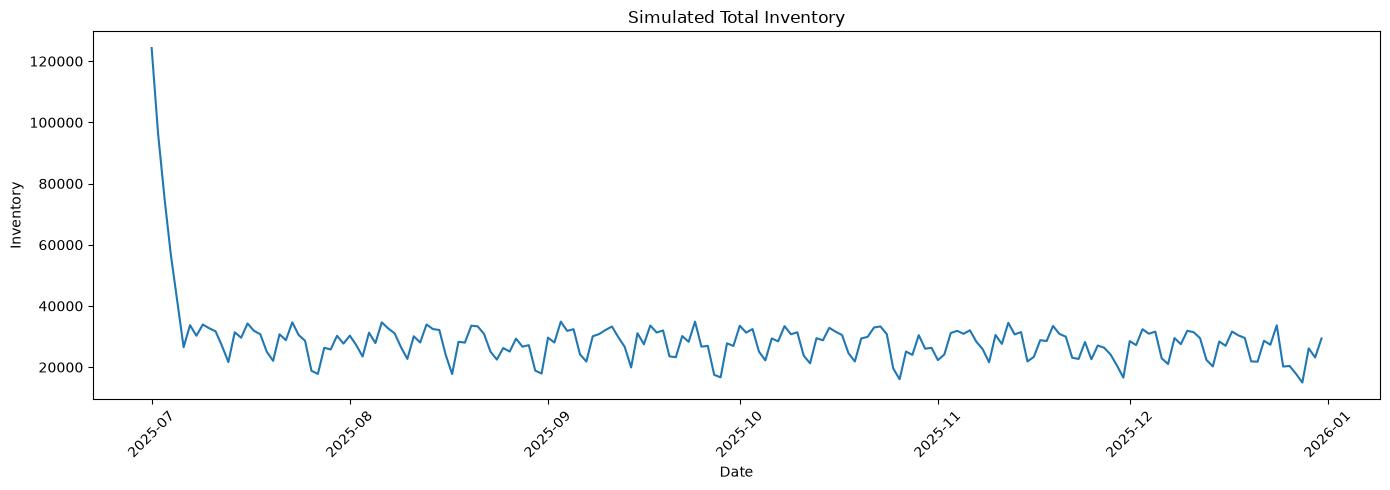

In [38]:
daily_inventory = (
    simulation_result
    .groupby("date")
    .agg(
        total_inventory=("closing_stock", "sum"),
        inventory_value=("inventory_value", "sum"),
        total_demand=("demand", "sum"),
        stockout_quantity=("stockout_quantity", "sum"),
        order_quantity=("order_quantity", "sum"),
    )
    .reset_index()
)

plt.figure(figsize=(14, 5))

plt.plot(
    daily_inventory["date"],
    daily_inventory["total_inventory"]
)

plt.title("Simulated Total Inventory")
plt.xlabel("Date")
plt.ylabel("Inventory")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

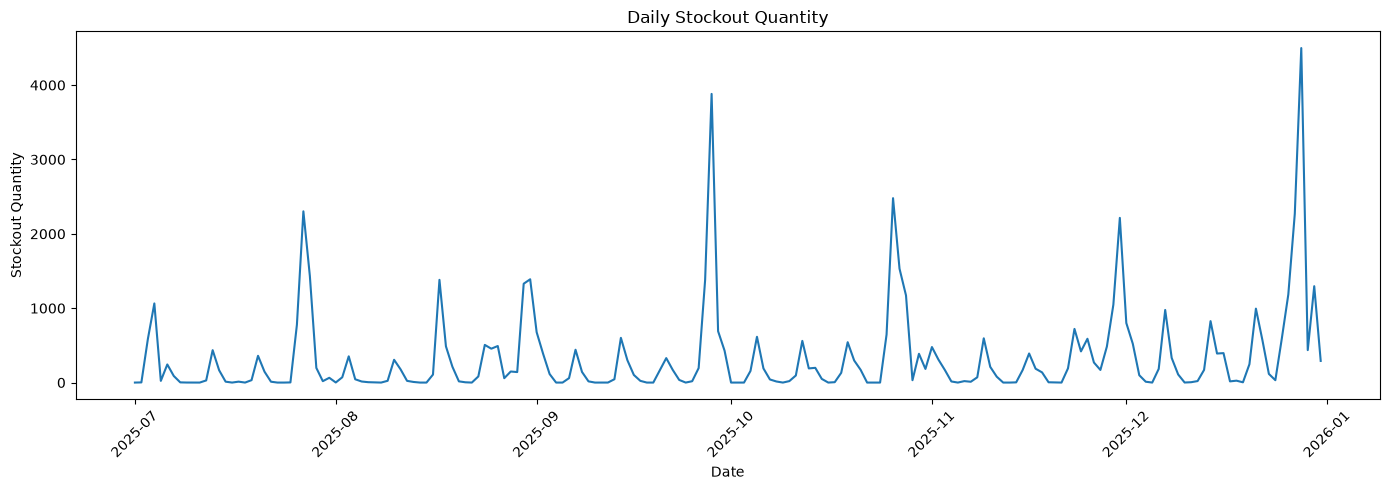

In [39]:
plt.figure(figsize=(14, 5))

plt.plot(
    daily_inventory["date"],
    daily_inventory["stockout_quantity"]
)

plt.title("Daily Stockout Quantity")
plt.xlabel("Date")
plt.ylabel("Stockout Quantity")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

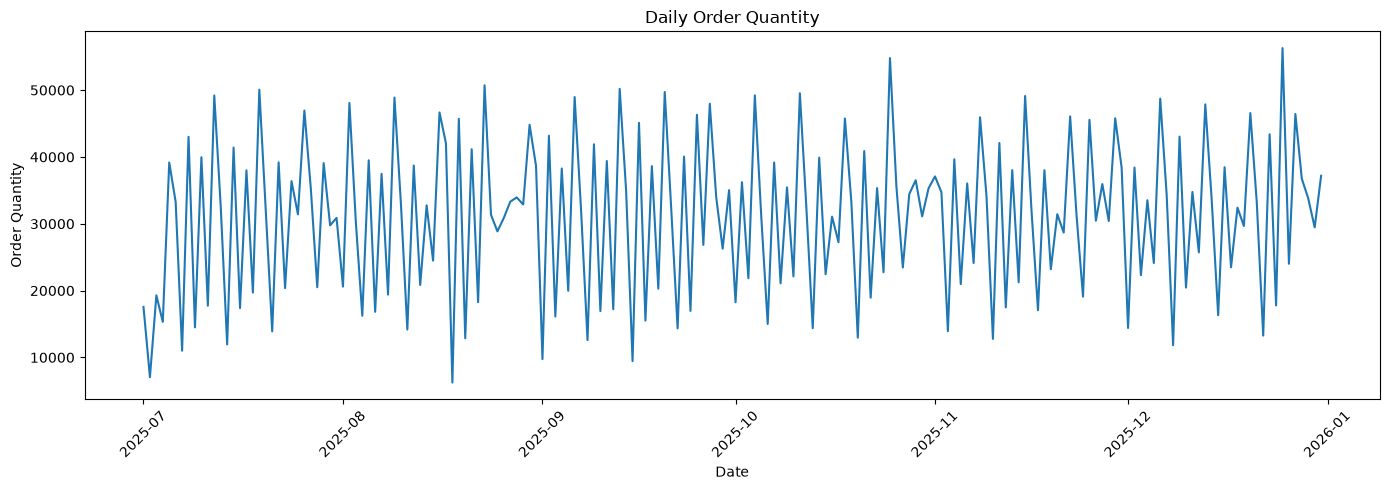

In [40]:
plt.figure(figsize=(14, 5))

plt.plot(
    daily_inventory["date"],
    daily_inventory["order_quantity"]
)

plt.title("Daily Order Quantity")
plt.xlabel("Date")
plt.ylabel("Order Quantity")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [41]:
# ============================================================
# Flexible Inventory Policy Simulator
# ============================================================

def simulate_inventory_policy_scenario(
    simulation_grid,
    train_usage,
    ingredients,
    initial_inventory,
    service_level_z=1.645,
    review_period_days=1,
):
    """
    Simulate an (s, S) inventory policy.

    Reorder Point:
        ROP = mean_daily_usage * lead_time
              + z * std_daily_usage * sqrt(lead_time)

    Target Stock:
        mean_daily_usage * (lead_time + review_period)
        + z * std_daily_usage * sqrt(lead_time + review_period)

    Reorder when:
        Inventory Position <= ROP

    Order quantity:
        Target Stock - Inventory Position
    """

    # --------------------------------------------------------
    # Calculate historical statistics
    # --------------------------------------------------------

    stats = (
        train_usage
        .groupby(
            ["branch_id", "ingredient_id"],
            as_index=False
        )
        .agg(
            avg_daily_usage=("ingredient_usage", "mean"),
            std_daily_usage=("ingredient_usage", "std"),
        )
    )

    stats["std_daily_usage"] = (
        stats["std_daily_usage"].fillna(0)
    )

    stats = stats.merge(
        ingredients[
            [
                "ingredient_id",
                "lead_time_days",
                "unit_cost",
            ]
        ],
        on="ingredient_id",
        how="left"
    )

    # --------------------------------------------------------
    # Reorder Point
    # --------------------------------------------------------

    stats["safety_stock"] = (
        service_level_z
        * stats["std_daily_usage"]
        * np.sqrt(stats["lead_time_days"])
    )

    stats["reorder_point"] = (
        stats["avg_daily_usage"]
        * stats["lead_time_days"]
        + stats["safety_stock"]
    )

    # --------------------------------------------------------
    # Target Stock
    # --------------------------------------------------------

    coverage_days = (
        stats["lead_time_days"]
        + review_period_days
    )

    stats["target_stock"] = (
        stats["avg_daily_usage"]
        * coverage_days
        +
        service_level_z
        * stats["std_daily_usage"]
        * np.sqrt(coverage_days)
    )

    # --------------------------------------------------------
    # Convert policy to dictionary
    # --------------------------------------------------------

    policy_lookup = {
        (row.branch_id, row.ingredient_id): row
        for row in stats.itertuples(index=False)
    }

    initial_lookup = {
        (row.branch_id, row.ingredient_id): float(row.initial_stock)
        for row in initial_inventory.itertuples(index=False)
    }

    # --------------------------------------------------------
    # State
    # --------------------------------------------------------

    on_hand = initial_lookup.copy()

    # arrival_date -> {(branch, ingredient): quantity}
    pending_orders = {}

    results = []

    # --------------------------------------------------------
    # Daily simulation
    # --------------------------------------------------------

    for current_date in sorted(
        simulation_grid["date"].unique()
    ):

        daily_rows = simulation_grid[
            simulation_grid["date"] == current_date
        ]

        # ====================================================
        # Receive orders
        # ====================================================

        arrivals_today = pending_orders.pop(
            current_date,
            {}
        )

        received_today = {}

        for key, quantity in arrivals_today.items():

            on_hand[key] = (
                on_hand.get(key, 0.0)
                + quantity
            )

            received_today[key] = quantity

        # ====================================================
        # Process branch × ingredient
        # ====================================================

        for row in daily_rows.itertuples(index=False):

            key = (
                row.branch_id,
                row.ingredient_id
            )

            policy = policy_lookup[key]

            current_stock = on_hand.get(
                key,
                0.0
            )

            demand = float(row.ingredient_usage)

            received = received_today.get(
                key,
                0.0
            )

            # =================================================
            # Consume demand
            # =================================================

            actual_usage = min(
                current_stock,
                demand
            )

            stockout_quantity = max(
                0.0,
                demand - current_stock
            )

            current_stock -= actual_usage

            # =================================================
            # Calculate on-order inventory
            # =================================================

            on_order = 0.0

            for orders in pending_orders.values():

                on_order += orders.get(
                    key,
                    0.0
                )

            inventory_position = (
                current_stock
                + on_order
            )

            # =================================================
            # Reorder decision
            # =================================================

            order_quantity = 0.0

            if inventory_position <= policy.reorder_point:

                order_quantity = max(
                    0.0,
                    policy.target_stock
                    - inventory_position
                )

                if order_quantity > 0:

                    arrival_date = (
                        current_date
                        + pd.Timedelta(
                            days=int(
                                policy.lead_time_days
                            )
                        )
                    )

                    if arrival_date not in pending_orders:
                        pending_orders[arrival_date] = {}

                    pending_orders[arrival_date][key] = (
                        pending_orders[arrival_date].get(
                            key,
                            0.0
                        )
                        + order_quantity
                    )

                    on_order += order_quantity

                    inventory_position = (
                        current_stock
                        + on_order
                    )

            # =================================================
            # Inventory value
            # =================================================

            inventory_value = (
                current_stock
                * policy.unit_cost
            )

            results.append(
                {
                    "date": current_date,
                    "branch_id": row.branch_id,
                    "ingredient_id": row.ingredient_id,
                    "demand": demand,
                    "actual_usage": actual_usage,
                    "received_stock": received,
                    "stockout_quantity": stockout_quantity,
                    "closing_stock": current_stock,
                    "on_order": on_order,
                    "inventory_position": inventory_position,
                    "order_quantity": order_quantity,
                    "inventory_value": inventory_value,
                }
            )

            on_hand[key] = current_stock

    return pd.DataFrame(results), stats

In [42]:
# ============================================================
# Policy scenarios
# ============================================================

scenarios = {
    "Conservative (95%)": {
        "z": 1.645,
        "review_period": 1,
    },
    "Balanced (90%)": {
        "z": 1.282,
        "review_period": 1,
    },
    "Lean (85%)": {
        "z": 1.036,
        "review_period": 1,
    },
}

print("Scenarios:")
for name, params in scenarios.items():
    print(
        f"{name}: "
        f"z={params['z']}, "
        f"review={params['review_period']} day"
    )

Scenarios:
Conservative (95%): z=1.645, review=1 day
Balanced (90%): z=1.282, review=1 day
Lean (85%): z=1.036, review=1 day


In [43]:
# ============================================================
# Run policy scenarios
# ============================================================

scenario_results = {}

for scenario_name, params in scenarios.items():

    print(f"Running: {scenario_name}")

    result, policy_stats = simulate_inventory_policy_scenario(
        simulation_grid=simulation_grid,
        train_usage=train_usage,
        ingredients=ingredients,
        initial_inventory=initial_inventory,
        service_level_z=params["z"],
        review_period_days=params["review_period"],
    )

    scenario_results[scenario_name] = {
        "result": result,
        "policy": policy_stats,
    }

print("\nAll scenarios completed.")

Running: Conservative (95%)
Running: Balanced (90%)
Running: Lean (85%)

All scenarios completed.


In [44]:
# ============================================================
# Evaluate all policies
# ============================================================

comparison = []

for scenario_name, scenario in scenario_results.items():

    result = scenario["result"]

    total_demand = result["demand"].sum()

    total_stockout = (
        result["stockout_quantity"].sum()
    )

    stockout_rate = (
        total_stockout / total_demand
        if total_demand > 0
        else 0
    )

    service_level = 1 - stockout_rate

    comparison.append(
        {
            "policy": scenario_name,
            "total_demand": total_demand,
            "stockout_quantity": total_stockout,
            "stockout_rate": stockout_rate,
            "service_level": service_level,
            "avg_inventory": result[
                "closing_stock"
            ].mean(),
            "avg_inventory_value": result[
                "inventory_value"
            ].mean(),
            "order_events": (
                result["order_quantity"] > 0
            ).sum(),
            "total_order_quantity": result[
                "order_quantity"
            ].sum(),
        }
    )

comparison_df = pd.DataFrame(comparison)

comparison_df

,policy,total_demand,stockout_quantity,stockout_rate,service_level,avg_inventory,avg_inventory_value,order_events,total_order_quantity
0,Conservative (95%),"5,823,147.7438","62,135.6411",0.0107,0.9893,96.6632,"2,632,457.5731",36205,"5,713,044.0896"
1,Balanced (90%),"5,823,147.7438","90,364.1071",0.0155,0.9845,89.1614,"2,429,069.3739",37050,"5,681,948.8985"
2,Lean (85%),"5,823,147.7438","114,011.8957",0.0196,0.9804,84.3236,"2,294,689.7429",37604,"5,656,368.8566"


In [45]:
# ============================================================
# Formatted comparison
# ============================================================

comparison_display = comparison_df.copy()

comparison_display["service_level"] = (
    comparison_display["service_level"] * 100
)

comparison_display["stockout_rate"] = (
    comparison_display["stockout_rate"] * 100
)

comparison_display[
    [
        "total_demand",
        "stockout_quantity",
        "avg_inventory",
        "avg_inventory_value",
        "total_order_quantity",
    ]
] = comparison_display[
    [
        "total_demand",
        "stockout_quantity",
        "avg_inventory",
        "avg_inventory_value",
        "total_order_quantity",
    ]
].round(2)

comparison_display[
    [
        "service_level",
        "stockout_rate",
    ]
] = comparison_display[
    [
        "service_level",
        "stockout_rate",
    ]
].round(3)

comparison_display

,policy,total_demand,stockout_quantity,stockout_rate,service_level,avg_inventory,avg_inventory_value,order_events,total_order_quantity
0,Conservative (95%),"5,823,147.7400","62,135.6400",1.0670,98.9330,96.6600,"2,632,457.5700",36205,"5,713,044.0900"
1,Balanced (90%),"5,823,147.7400","90,364.1100",1.5520,98.4480,89.1600,"2,429,069.3700",37050,"5,681,948.9000"
2,Lean (85%),"5,823,147.7400","114,011.9000",1.9580,98.0420,84.3200,"2,294,689.7400",37604,"5,656,368.8600"


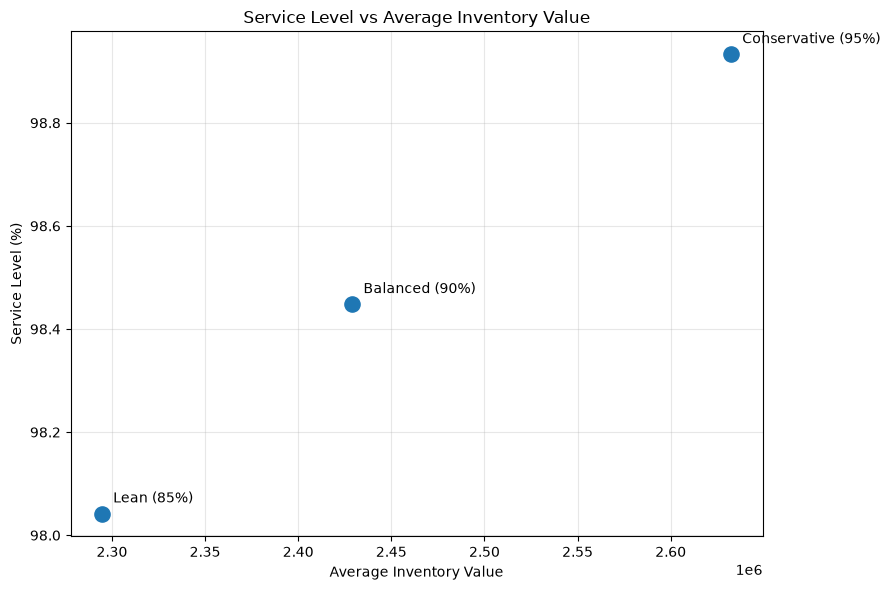

In [46]:
# ============================================================
# Service level vs inventory value
# ============================================================

plt.figure(figsize=(9, 6))

plt.scatter(
    comparison_df["avg_inventory_value"],
    comparison_df["service_level"] * 100,
    s=120
)

for _, row in comparison_df.iterrows():

    plt.annotate(
        row["policy"],
        (
            row["avg_inventory_value"],
            row["service_level"] * 100
        ),
        xytext=(8, 8),
        textcoords="offset points"
    )

plt.title(
    "Service Level vs Average Inventory Value"
)

plt.xlabel(
    "Average Inventory Value"
)

plt.ylabel(
    "Service Level (%)"
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

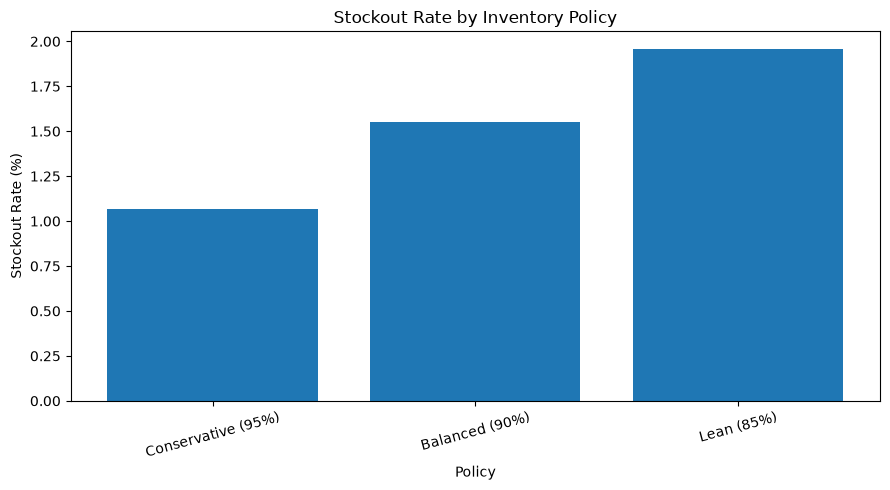

In [47]:
# ============================================================
# Stockout rate comparison
# ============================================================

plt.figure(figsize=(9, 5))

plt.bar(
    comparison_df["policy"],
    comparison_df["stockout_rate"] * 100
)

plt.title("Stockout Rate by Inventory Policy")

plt.xlabel("Policy")
plt.ylabel("Stockout Rate (%)")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

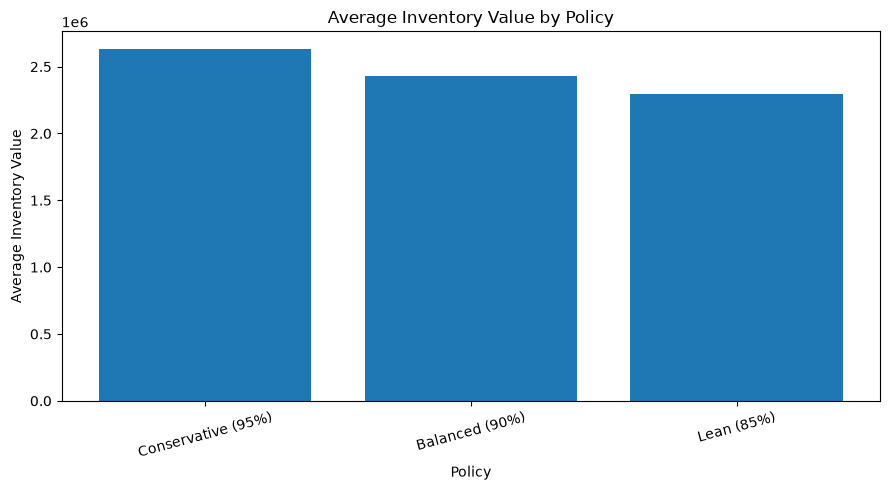

In [48]:
# ============================================================
# Average inventory value comparison
# ============================================================

plt.figure(figsize=(9, 5))

plt.bar(
    comparison_df["policy"],
    comparison_df["avg_inventory_value"]
)

plt.title(
    "Average Inventory Value by Policy"
)

plt.xlabel("Policy")
plt.ylabel("Average Inventory Value")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [49]:
# ============================================================
# Policy selection
# ============================================================

SERVICE_LEVEL_TARGET = 0.95

eligible_policies = comparison_df[
    comparison_df["service_level"]
    >= SERVICE_LEVEL_TARGET
].copy()

eligible_policies = eligible_policies.sort_values(
    "avg_inventory_value"
)

print("===== ELIGIBLE POLICIES =====")

eligible_policies[
    [
        "policy",
        "service_level",
        "stockout_rate",
        "avg_inventory",
        "avg_inventory_value",
        "order_events",
        "total_order_quantity",
    ]
]

===== ELIGIBLE POLICIES =====


,policy,service_level,stockout_rate,avg_inventory,avg_inventory_value,order_events,total_order_quantity
2,Lean (85%),0.9804,0.0196,84.3236,"2,294,689.7429",37604,"5,656,368.8566"
1,Balanced (90%),0.9845,0.0155,89.1614,"2,429,069.3739",37050,"5,681,948.8985"
0,Conservative (95%),0.9893,0.0107,96.6632,"2,632,457.5731",36205,"5,713,044.0896"


In [50]:
if len(eligible_policies) > 0:

    selected_policy = (
        eligible_policies.iloc[0]["policy"]
    )

    print(
        f"\nSelected policy: {selected_policy}"
    )

else:

    print(
        "\nNo policy reached the "
        "95% service-level target."
    )


Selected policy: Lean (85%)


In [51]:
# ============================================================
# Fine-grained Service Level Sensitivity Analysis
# ============================================================

sensitivity_scenarios = {
    "80%": 0.842,
    "85%": 1.036,
    "90%": 1.282,
    "95%": 1.645,
    "97.5%": 1.960,
    "99%": 2.326,
}

sensitivity_results = []

for scenario_name, z_value in sensitivity_scenarios.items():

    print(f"Running sensitivity scenario: {scenario_name}")

    result, policy_stats = simulate_inventory_policy_scenario(
        simulation_grid=simulation_grid,
        train_usage=train_usage,
        ingredients=ingredients,
        initial_inventory=initial_inventory,
        service_level_z=z_value,
        review_period_days=1,
    )

    total_demand = result["demand"].sum()
    total_stockout = result["stockout_quantity"].sum()

    stockout_rate = (
        total_stockout / total_demand
    )

    service_level = 1 - stockout_rate

    sensitivity_results.append(
        {
            "target_service_level": scenario_name,
            "z_value": z_value,
            "actual_service_level": service_level,
            "stockout_rate": stockout_rate,
            "stockout_quantity": total_stockout,
            "avg_inventory": result[
                "closing_stock"
            ].mean(),
            "avg_inventory_value": result[
                "inventory_value"
            ].mean(),
            "order_events": (
                result["order_quantity"] > 0
            ).sum(),
            "total_order_quantity": result[
                "order_quantity"
            ].sum(),
        }
    )

sensitivity_df = pd.DataFrame(
    sensitivity_results
)

sensitivity_df

Running sensitivity scenario: 80%
Running sensitivity scenario: 85%
Running sensitivity scenario: 90%
Running sensitivity scenario: 95%
Running sensitivity scenario: 97.5%
Running sensitivity scenario: 99%


,target_service_level,z_value,actual_service_level,stockout_rate,stockout_quantity,avg_inventory,avg_inventory_value,order_events,total_order_quantity
0,80%,0.8420,0.9765,0.0235,"136,929.3523",80.7209,"2,195,250.4586",38019,"5,631,990.3517"
1,85%,1.0360,0.9804,0.0196,"114,011.8957",84.3236,"2,294,689.7429",37604,"5,656,368.8566"
2,90%,1.2820,0.9845,0.0155,"90,364.1071",89.1614,"2,429,069.3739",37050,"5,681,948.8985"
3,95%,1.6450,0.9893,0.0107,"62,135.6411",96.6632,"2,632,457.5731",36205,"5,713,044.0896"
4,97.5%,1.9600,0.9924,0.0076,"44,319.3150",103.5692,"2,821,388.9630",35489,"5,732,552.9306"
5,99%,2.3260,0.9950,0.0050,"29,138.2974",111.9949,"3,050,601.5052",34682,"5,749,932.6618"


In [52]:
# ============================================================
# Sensitivity analysis display
# ============================================================

sensitivity_display = sensitivity_df.copy()

sensitivity_display["actual_service_level"] = (
    sensitivity_display["actual_service_level"] * 100
)

sensitivity_display["stockout_rate"] = (
    sensitivity_display["stockout_rate"] * 100
)

numeric_columns = [
    "stockout_quantity",
    "avg_inventory",
    "avg_inventory_value",
    "total_order_quantity",
]

sensitivity_display[numeric_columns] = (
    sensitivity_display[numeric_columns].round(2)
)

sensitivity_display[
    [
        "actual_service_level",
        "stockout_rate",
    ]
] = sensitivity_display[
    [
        "actual_service_level",
        "stockout_rate",
    ]
].round(3)

sensitivity_display

,target_service_level,z_value,actual_service_level,stockout_rate,stockout_quantity,avg_inventory,avg_inventory_value,order_events,total_order_quantity
0,80%,0.8420,97.6490,2.3510,"136,929.3500",80.7200,"2,195,250.4600",38019,"5,631,990.3500"
1,85%,1.0360,98.0420,1.9580,"114,011.9000",84.3200,"2,294,689.7400",37604,"5,656,368.8600"
2,90%,1.2820,98.4480,1.5520,"90,364.1100",89.1600,"2,429,069.3700",37050,"5,681,948.9000"
3,95%,1.6450,98.9330,1.0670,"62,135.6400",96.6600,"2,632,457.5700",36205,"5,713,044.0900"
4,97.5%,1.9600,99.2390,0.7610,"44,319.3200",103.5700,"2,821,388.9600",35489,"5,732,552.9300"
5,99%,2.3260,99.5000,0.5000,"29,138.3000",111.9900,"3,050,601.5100",34682,"5,749,932.6600"


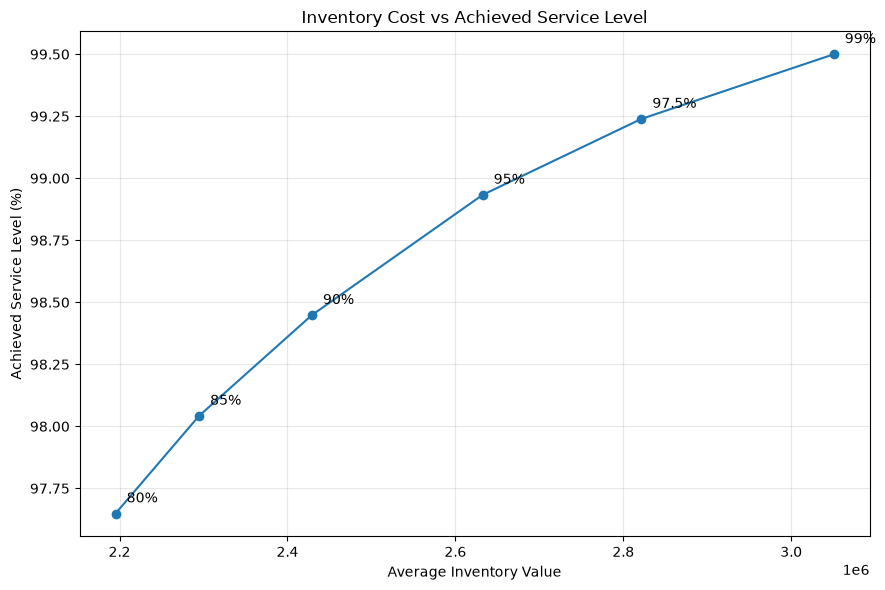

In [53]:
# ============================================================
# Service level vs inventory value
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    sensitivity_df["avg_inventory_value"],
    sensitivity_df["actual_service_level"] * 100,
    marker="o"
)

for _, row in sensitivity_df.iterrows():

    plt.annotate(
        row["target_service_level"],
        (
            row["avg_inventory_value"],
            row["actual_service_level"] * 100
        ),
        xytext=(8, 8),
        textcoords="offset points"
    )

plt.title(
    "Inventory Cost vs Achieved Service Level"
)

plt.xlabel(
    "Average Inventory Value"
)

plt.ylabel(
    "Achieved Service Level (%)"
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [54]:
FINAL_SERVICE_LEVEL = 0.85
FINAL_Z = 1.036

print("Final Inventory Policy")
print("=" * 40)
print(f"Target service level : {FINAL_SERVICE_LEVEL:.0%}")
print(f"Z-value              : {FINAL_Z:.3f}")
print("Policy               : Lean / Balanced")

Final Inventory Policy
Target service level : 85%
Z-value              : 1.036
Policy               : Lean / Balanced


In [55]:
FINAL_POLICY_NAME = "Lean 85%"
FINAL_SERVICE_LEVEL = 0.85
FINAL_Z = 1.036
FINAL_REVIEW_PERIOD = 1

print("Final Inventory Policy")
print("=" * 40)
print(f"Policy               : {FINAL_POLICY_NAME}")
print(f"Target service level : {FINAL_SERVICE_LEVEL:.0%}")
print(f"Z-value              : {FINAL_Z:.3f}")
print(f"Review period        : {FINAL_REVIEW_PERIOD} day")

Final Inventory Policy
Policy               : Lean 85%
Target service level : 85%
Z-value              : 1.036
Review period        : 1 day


In [56]:
POLICY_Z = FINAL_Z
REVIEW_PERIOD = FINAL_REVIEW_PERIOD

# Historical demand for parameter estimation
train_demand = ingredient_demand[
    ingredient_demand["date"] <= pd.Timestamp("2025-06-30")
].copy()

# Demand statistics per branch + ingredient
inventory_policy = (
    train_demand
    .groupby(["branch_id", "ingredient_id"])["ingredient_usage"]
    .agg(
        avg_daily_usage="mean",
        std_daily_usage="std"
    )
    .reset_index()
)

# Lead time and cost
ingredient_info = ingredients[
    ["ingredient_id", "lead_time_days", "unit_cost"]
].copy()

inventory_policy = inventory_policy.merge(
    ingredient_info,
    on="ingredient_id",
    how="left"
)

inventory_policy["std_daily_usage"] = (
    inventory_policy["std_daily_usage"]
    .fillna(0)
)

# Safety stock
inventory_policy["safety_stock"] = (
    POLICY_Z
    * inventory_policy["std_daily_usage"]
    * np.sqrt(inventory_policy["lead_time_days"])
)

# Lead time demand
inventory_policy["lead_time_demand"] = (
    inventory_policy["avg_daily_usage"]
    * inventory_policy["lead_time_days"]
)

# Reorder point
inventory_policy["reorder_point"] = (
    inventory_policy["lead_time_demand"]
    + inventory_policy["safety_stock"]
)

# Target stock
inventory_policy["target_stock"] = (
    inventory_policy["avg_daily_usage"]
    * (
        inventory_policy["lead_time_days"]
        + REVIEW_PERIOD
    )
    +
    POLICY_Z
    * inventory_policy["std_daily_usage"]
    * np.sqrt(
        inventory_policy["lead_time_days"]
        + REVIEW_PERIOD
    )
)

# Current inventory at end of training
current_inventory = (
    inventory[
        inventory["date"] == pd.Timestamp("2025-06-30")
    ][
        [
            "branch_id",
            "ingredient_id",
            "closing_stock"
        ]
    ]
    .rename(
        columns={
            "closing_stock": "current_stock"
        }
    )
)

inventory_policy = inventory_policy.merge(
    current_inventory,
    on=["branch_id", "ingredient_id"],
    how="left"
)

inventory_policy["current_stock"] = (
    inventory_policy["current_stock"]
    .fillna(0)
)

# Assume no outstanding orders for recommendation snapshot
inventory_policy["on_order"] = 0.0

inventory_policy["inventory_position"] = (
    inventory_policy["current_stock"]
    + inventory_policy["on_order"]
)

# Recommended order quantity
inventory_policy["order_quantity"] = (
    inventory_policy["target_stock"]
    - inventory_policy["inventory_position"]
).clip(lower=0)

# Operational action
inventory_policy["action"] = np.where(
    inventory_policy["inventory_position"]
    <= inventory_policy["reorder_point"],
    "ORDER",
    "HOLD"
)

# Only order when action is ORDER
inventory_policy["recommended_order_quantity"] = np.where(
    inventory_policy["action"] == "ORDER",
    inventory_policy["order_quantity"],
    0
)

# Estimated order value
inventory_policy["estimated_order_value"] = (
    inventory_policy["recommended_order_quantity"]
    * inventory_policy["unit_cost"]
)

inventory_policy.head()

,branch_id,ingredient_id,avg_daily_usage,std_daily_usage,lead_time_days,unit_cost,safety_stock,lead_time_demand,reorder_point,target_stock,current_stock,on_order,inventory_position,order_quantity,action,recommended_order_quantity,estimated_order_value
0,B001,I001,124.8576,19.6717,2,"30,346.5300",28.8216,249.7152,278.5367,409.8718,555.2800,0.0000,555.2800,0.0000,HOLD,0.0000,0.0000
1,B001,I002,86.9859,14.5507,4,"18,255.0200",30.1490,347.9438,378.0927,468.6373,525.1000,0.0000,525.1000,0.0000,HOLD,0.0000,0.0000
2,B001,I003,90.6306,16.3115,1,"6,026.0100",16.8987,90.6306,107.5293,205.1596,472.2800,0.0000,472.2800,0.0000,HOLD,0.0000,0.0000
3,B001,I004,58.7493,10.7283,4,"32,648.1500",22.2290,234.9972,257.2262,318.5992,402.8800,0.0000,402.8800,0.0000,HOLD,0.0000,0.0000
4,B001,I005,140.2401,22.8906,4,"42,146.1000",47.4293,560.9604,608.3897,754.2281,329.3700,0.0000,329.3700,424.8581,ORDER,424.8581,"17,906,110.9916"


In [57]:
print("Recommendation shape:", inventory_policy.shape)

print(
    inventory_policy[
        [
            "branch_id",
            "ingredient_id",
            "current_stock",
            "avg_daily_usage",
            "lead_time_days",
            "reorder_point",
            "target_stock",
            "recommended_order_quantity",
            "action"
        ]
    ].head(20)
)

Recommendation shape: (300, 17)
   branch_id ingredient_id  current_stock  avg_daily_usage  lead_time_days  \
0       B001          I001       555.2800         124.8576               2   
1       B001          I002       525.1000          86.9859               4   
2       B001          I003       472.2800          90.6306               1   
3       B001          I004       402.8800          58.7493               4   
4       B001          I005       329.3700         140.2401               4   
5       B001          I006       513.2700          81.7765               2   
6       B001          I007       308.0000          83.5774               3   
7       B001          I008       507.2300          85.7093               4   
8       B001          I009       420.0100          71.6245               4   
9       B001          I010       507.7600          71.5709               2   
10      B001          I011       979.5600         141.7518               1   
11      B001          I012      

In [58]:
FINAL_POLICY_NAME = "Lean 85%"
FINAL_SERVICE_LEVEL = 0.85
FINAL_Z = 1.036
FINAL_REVIEW_PERIOD = 1

print("Final Inventory Policy")
print("=" * 40)
print(f"Policy               : {FINAL_POLICY_NAME}")
print(f"Target service level : {FINAL_SERVICE_LEVEL:.0%}")
print(f"Z-value              : {FINAL_Z:.3f}")
print(f"Review period        : {FINAL_REVIEW_PERIOD} day")

Final Inventory Policy
Policy               : Lean 85%
Target service level : 85%
Z-value              : 1.036
Review period        : 1 day


In [59]:
POLICY_Z = FINAL_Z
REVIEW_PERIOD = FINAL_REVIEW_PERIOD

# 1. Gunakan data demand sampai akhir periode training
train_demand = ingredient_demand[
    ingredient_demand["date"] <= pd.Timestamp("2025-06-30")
].copy()

# 2. Hitung statistik penggunaan per branch + ingredient
inventory_policy = (
    train_demand
    .groupby(["branch_id", "ingredient_id"])["ingredient_usage"]
    .agg(
        avg_daily_usage="mean",
        std_daily_usage="std"
    )
    .reset_index()
)

# 3. Tambahkan lead time dan unit cost
ingredient_info = ingredients[
    ["ingredient_id", "lead_time_days", "unit_cost"]
].copy()

inventory_policy = inventory_policy.merge(
    ingredient_info,
    on="ingredient_id",
    how="left"
)

inventory_policy["std_daily_usage"] = (
    inventory_policy["std_daily_usage"]
    .fillna(0)
)

# 4. Safety stock
inventory_policy["safety_stock"] = (
    POLICY_Z
    * inventory_policy["std_daily_usage"]
    * np.sqrt(inventory_policy["lead_time_days"])
)

# 5. Lead-time demand
inventory_policy["lead_time_demand"] = (
    inventory_policy["avg_daily_usage"]
    * inventory_policy["lead_time_days"]
)

# 6. Reorder Point
inventory_policy["reorder_point"] = (
    inventory_policy["lead_time_demand"]
    + inventory_policy["safety_stock"]
)

# 7. Target Stock
inventory_policy["target_stock"] = (
    inventory_policy["avg_daily_usage"]
    * (
        inventory_policy["lead_time_days"]
        + REVIEW_PERIOD
    )
    +
    POLICY_Z
    * inventory_policy["std_daily_usage"]
    * np.sqrt(
        inventory_policy["lead_time_days"]
        + REVIEW_PERIOD
    )
)

# 8. Ambil kondisi inventory pada akhir training
current_inventory = (
    inventory[
        inventory["date"] == pd.Timestamp("2025-06-30")
    ][
        [
            "branch_id",
            "ingredient_id",
            "closing_stock"
        ]
    ]
    .rename(
        columns={
            "closing_stock": "current_stock"
        }
    )
)

inventory_policy = inventory_policy.merge(
    current_inventory,
    on=["branch_id", "ingredient_id"],
    how="left"
)

inventory_policy["current_stock"] = (
    inventory_policy["current_stock"]
    .fillna(0)
)

# 9. Inventory position
# Untuk snapshot sederhana, belum memasukkan outstanding PO.
inventory_policy["on_order"] = 0.0

inventory_policy["inventory_position"] = (
    inventory_policy["current_stock"]
    + inventory_policy["on_order"]
)

# 10. Hitung order quantity
inventory_policy["order_quantity"] = (
    inventory_policy["target_stock"]
    - inventory_policy["inventory_position"]
).clip(lower=0)

# 11. Tentukan action
inventory_policy["action"] = np.where(
    inventory_policy["inventory_position"]
    <= inventory_policy["reorder_point"],
    "ORDER",
    "HOLD"
)

# 12. Hanya rekomendasikan quantity jika perlu order
inventory_policy["recommended_order_quantity"] = np.where(
    inventory_policy["action"] == "ORDER",
    inventory_policy["order_quantity"],
    0
)

# 13. Estimasi nilai order
inventory_policy["estimated_order_value"] = (
    inventory_policy["recommended_order_quantity"]
    * inventory_policy["unit_cost"]
)

print("Recommendation table created.")
print("Shape:", inventory_policy.shape)

inventory_policy.head()

Recommendation table created.
Shape: (300, 17)


,branch_id,ingredient_id,avg_daily_usage,std_daily_usage,lead_time_days,unit_cost,safety_stock,lead_time_demand,reorder_point,target_stock,current_stock,on_order,inventory_position,order_quantity,action,recommended_order_quantity,estimated_order_value
0,B001,I001,124.8576,19.6717,2,"30,346.5300",28.8216,249.7152,278.5367,409.8718,555.2800,0.0000,555.2800,0.0000,HOLD,0.0000,0.0000
1,B001,I002,86.9859,14.5507,4,"18,255.0200",30.1490,347.9438,378.0927,468.6373,525.1000,0.0000,525.1000,0.0000,HOLD,0.0000,0.0000
2,B001,I003,90.6306,16.3115,1,"6,026.0100",16.8987,90.6306,107.5293,205.1596,472.2800,0.0000,472.2800,0.0000,HOLD,0.0000,0.0000
3,B001,I004,58.7493,10.7283,4,"32,648.1500",22.2290,234.9972,257.2262,318.5992,402.8800,0.0000,402.8800,0.0000,HOLD,0.0000,0.0000
4,B001,I005,140.2401,22.8906,4,"42,146.1000",47.4293,560.9604,608.3897,754.2281,329.3700,0.0000,329.3700,424.8581,ORDER,424.8581,"17,906,110.9916"


In [60]:
recommendation_columns = [
    "branch_id",
    "ingredient_id",
    "current_stock",
    "avg_daily_usage",
    "lead_time_days",
    "reorder_point",
    "target_stock",
    "inventory_position",
    "recommended_order_quantity",
    "estimated_order_value",
    "action"
]

display(
    inventory_policy[
        recommendation_columns
    ]
    .sort_values(
        ["action", "recommended_order_quantity"],
        ascending=[True, False]
    )
    .head(30)
)

,branch_id,ingredient_id,current_stock,avg_daily_usage,lead_time_days,reorder_point,target_stock,inventory_position,recommended_order_quantity,estimated_order_value,action
0,B001,I001,555.2800,124.8576,2,278.5367,409.8718,555.2800,0.0000,0.0000,HOLD
1,B001,I002,525.1000,86.9859,4,378.0927,468.6373,525.1000,0.0000,0.0000,HOLD
2,B001,I003,472.2800,90.6306,1,107.5293,205.1596,472.2800,0.0000,0.0000,HOLD
3,B001,I004,402.8800,58.7493,4,257.2262,318.5992,402.8800,0.0000,0.0000,HOLD
5,B001,I006,513.2700,81.7765,2,185.1018,271.7213,513.2700,0.0000,0.0000,HOLD
6,B001,I007,308.0000,83.5774,3,277.1624,364.8286,308.0000,0.0000,0.0000,HOLD
7,B001,I008,507.2300,85.7093,4,374.3033,463.7267,507.2300,0.0000,0.0000,HOLD
8,B001,I009,420.0100,71.6245,4,314.7095,389.6639,420.0100,0.0000,0.0000,HOLD
9,B001,I010,507.7600,71.5709,2,163.7437,239.9448,507.7600,0.0000,0.0000,HOLD
10,B001,I011,979.5600,141.7518,1,165.6957,317.3654,979.5600,0.0000,0.0000,HOLD


In [61]:
summary = {
    "Total combinations": len(inventory_policy),
    "ORDER recommendations": (
        inventory_policy["action"] == "ORDER"
    ).sum(),
    "HOLD recommendations": (
        inventory_policy["action"] == "HOLD"
    ).sum(),
    "Total recommended quantity": (
        inventory_policy["recommended_order_quantity"].sum()
    ),
    "Total estimated order value": (
        inventory_policy["estimated_order_value"].sum()
    )
}

for key, value in summary.items():
    if isinstance(value, (int, np.integer)):
        print(f"{key:30}: {value:,}")
    else:
        print(f"{key:30}: {value:,.2f}")

Total combinations            : 300
ORDER recommendations         : 29
HOLD recommendations          : 271
Total recommended quantity    : 5,845.23
Total estimated order value   : 135,203,470.41


In [62]:
# 1. HOLD harus memiliki recommended order quantity = 0
hold_invalid = inventory_policy[
    (inventory_policy["action"] == "HOLD") &
    (inventory_policy["recommended_order_quantity"] > 0)
]

# 2. ORDER harus memiliki inventory position <= reorder point
order_invalid = inventory_policy[
    (inventory_policy["action"] == "ORDER") &
    (inventory_policy["inventory_position"] > inventory_policy["reorder_point"])
]

# 3. Tidak boleh ada negative order quantity
negative_order = inventory_policy[
    inventory_policy["recommended_order_quantity"] < 0
]

# 4. Tidak boleh ada missing value pada kolom penting
required_columns = [
    "branch_id",
    "ingredient_id",
    "current_stock",
    "avg_daily_usage",
    "lead_time_days",
    "reorder_point",
    "target_stock",
    "inventory_position",
    "recommended_order_quantity",
    "estimated_order_value",
    "action"
]

missing_values = inventory_policy[required_columns].isna().sum().sum()

print("Recommendation Validation")
print("=" * 45)
print(f"Invalid HOLD recommendations : {len(hold_invalid)}")
print(f"Invalid ORDER recommendations: {len(order_invalid)}")
print(f"Negative order quantities    : {len(negative_order)}")
print(f"Missing required values      : {missing_values}")

if (
    len(hold_invalid) == 0
    and len(order_invalid) == 0
    and len(negative_order) == 0
    and missing_values == 0
):
    print("\nRECOMMENDATION VALIDATION PASSED")
else:
    print("\nRECOMMENDATION VALIDATION FAILED")

Recommendation Validation
Invalid HOLD recommendations : 0
Invalid ORDER recommendations: 0
Negative order quantities    : 0
Missing required values      : 0

RECOMMENDATION VALIDATION PASSED


In [63]:
order_recommendations = (
    inventory_policy[
        inventory_policy["action"] == "ORDER"
    ]
    .sort_values(
        "estimated_order_value",
        ascending=False
    )
)

print("Inventory Recommendation Summary")
print("=" * 45)

print(f"Policy                  : {FINAL_POLICY_NAME}")
print(f"Target service level    : {FINAL_SERVICE_LEVEL:.0%}")
print(f"Total branch-ingredients: {len(inventory_policy):,}")
print(f"Items requiring ORDER   : {len(order_recommendations):,}")
print(
    f"Items on HOLD           : "
    f"{(inventory_policy['action'] == 'HOLD').sum():,}"
)
print(
    f"Total order quantity    : "
    f"{order_recommendations['recommended_order_quantity'].sum():,.2f}"
)
print(
    f"Estimated order value   : "
    f"{order_recommendations['estimated_order_value'].sum():,.2f}"
)

print("\nTop 10 Order Recommendations:")
display(
    order_recommendations[
        [
            "branch_id",
            "ingredient_id",
            "current_stock",
            "avg_daily_usage",
            "lead_time_days",
            "reorder_point",
            "target_stock",
            "recommended_order_quantity",
            "estimated_order_value"
        ]
    ].head(10)
)

Inventory Recommendation Summary
Policy                  : Lean 85%
Target service level    : 85%
Total branch-ingredients: 300
Items requiring ORDER   : 29
Items on HOLD           : 271
Total order quantity    : 5,845.23
Estimated order value   : 135,203,470.41

Top 10 Order Recommendations:


,branch_id,ingredient_id,current_stock,avg_daily_usage,lead_time_days,reorder_point,target_stock,recommended_order_quantity,estimated_order_value
4,B001,I005,329.3700,140.2401,4,608.3897,754.2281,424.8581,"17,906,110.9916"
274,B010,I005,860.3000,221.3368,4,960.2753,"1,190.4562",330.1562,"13,914,796.2119"
98,B004,I009,227.2500,94.1447,4,415.8458,514.6253,287.3753,"8,031,996.6239"
128,B005,I009,290.2900,101.8917,4,447.4750,554.0773,263.7873,"7,372,722.4474"
271,B010,I002,340.7000,135.3350,4,587.3156,728.0773,387.3773,"7,071,580.3530"
37,B002,I008,261.2800,115.4571,4,502.8864,623.1897,361.9097,"6,501,234.0389"
247,B009,I008,348.9400,129.6220,4,566.0073,701.2382,352.2982,"6,328,576.3719"
71,B003,I012,214.5500,92.4480,3,307.5039,404.6176,190.0676,"6,186,080.4737"
54,B002,I025,231.6500,95.1348,3,317.4360,417.5261,185.8761,"5,551,125.7202"
153,B006,I004,265.7100,79.6818,4,347.5053,430.5839,164.8739,"5,382,828.3152"


In [65]:

import os
import sys
from pathlib import Path

if 'google.colab' in str(get_ipython()):
    print("Berjalan di Google Colab")
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = Path("/content/drive/MyDrive/PROJECTS/fb-intelligence")
else:
    print("Berjalan di Komputer Lokal")
    current_dir = Path.cwd()
    PROJECT_ROOT = current_dir.parent if current_dir.name == "notebooks" else current_dir

# Registrasikan Root Project ke Python Path & Ubah Working Directory
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

os.chdir(PROJECT_ROOT)

Berjalan di Komputer Lokal


In [66]:
from src.inventory.recommendation import calculate_inventory_policy

production_recommendation = calculate_inventory_policy(
    ingredient_demand=ingredient_demand,
    ingredients=ingredients,
    inventory=inventory,
    z_value=FINAL_Z,
    review_period=FINAL_REVIEW_PERIOD,
    cutoff_date="2025-06-30",
)

print("Production recommendation shape:")
print(production_recommendation.shape)

print("\nAction distribution:")
print(
    production_recommendation["action"]
    .value_counts()
)

print("\nTotal recommended quantity:")
print(
    production_recommendation[
        "recommended_order_quantity"
    ].sum()
)

print("\nTotal estimated order value:")
print(
    production_recommendation[
        "estimated_order_value"
    ].sum()
)

Production recommendation shape:
(300, 17)

Action distribution:
action
HOLD     271
ORDER     29
Name: count, dtype: int64

Total recommended quantity:
5845.232384712849

Total estimated order value:
135203470.41332662
